# Production LLM Observability & Evaluation with Arize Phoenix and Local Qwen Models

**A comprehensive tutorial from zero to production-grade LLM monitoring.**

This notebook teaches you how to observe, evaluate, and iterate on LLM applications
using entirely local infrastructure — no API keys, no cloud dependencies.

## What you'll learn

| Section | Topic | Key skill |
|---------|-------|-----------|
| 0 | The Phoenix Philosophy | Mental model for observability vs. evaluation |
| 1 | Instrumentation | Auto-capture every LLM call with OpenTelemetry |
| 2 | Datasets & Experiments | A/B test prompts with controlled variables |
| 3 | Evaluation Hierarchy | Deterministic → heuristic → LLM-as-judge |
| 4 | RAG Evaluation | Retrieval metrics + generation faithfulness |
| 5 | Agent Evaluation | Multi-step trajectory scoring |
| 6 | Hidden Features | Span-level evals, embedding viz, HITL |
| 7 | Meta-Evaluation | Validate the judge itself |
| 8 | Prompt Versioning | The iteration loop |

## Infrastructure

| Component | Details |
|-----------|---------|
| **LLM** | `unsloth/Qwen3.5-35B-A3B` via llama.cpp at `http://127.0.0.1:8001/v1` |
| **Phoenix** | Arize Phoenix at `http://localhost:6006` |
| **Tracing** | OpenTelemetry → Phoenix collector |
| **Hardware** | Apple M4 48GB |

---

---
## Section 0: The Phoenix Philosophy

### Logging vs. Tracing vs. Evaluation

Most developers start with `print()` statements. That's **logging** — recording what happened.
But LLM applications have a problem: a single user query might trigger 5+ internal steps
(embedding, retrieval, reranking, generation, guardrails). Logs tell you each step happened,
but not how they connect.

**Tracing** solves this. Think of it like a debugger's call stack, but for distributed systems:

```
User Query: "What causes earthquakes?"
└── Trace (end-to-end, 2.3s)
    ├── Span: embed_query (12ms)
    ├── Span: vector_search (45ms, returned 5 chunks)
    ├── Span: rerank (180ms, kept 3 chunks)
    └── Span: generate (2100ms, 847 tokens)
```

Each **span** is a timed operation. Together they form a **trace** — the complete story of one request.

**Evaluation** is the third layer. Tracing tells you *what* happened. Evaluation tells you
*how well* it happened. Was the retrieval relevant? Was the answer faithful to the context?
Did the model hallucinate?

### The Data Flow

```
Your Application                    Phoenix Server
     │                                   │
     ├─ LLM call ──→ OpenTelemetry ──→ Traces (stored)
     ├─ LLM call ──→ OpenTelemetry ──→ Traces (stored)
     │                                   │
     │                              Evaluations ←── Judge LLM
     │                                   │         (also local Qwen)
     │                              Scores attached
     │                              to traces/spans
     │                                   │
     └── Phoenix UI ←── Browse traces + scores + experiments
```

### Why a separate "Judge" model?

You can't ask a model to grade its own homework. Even when the judge IS the same model
(as in our case — we use Qwen for both generation and evaluation), the key difference is:

- **Generation** runs with the user's context and conversation history
- **Evaluation** runs with a carefully designed rubric prompt, comparing output against ground truth

The judge prompt structure forces systematic evaluation rather than "does this look right to me?"

> **Check Your Understanding:** Why might a model rate its own output highly even when it's wrong?
> Because it's optimized to produce confident-sounding text, not to detect its own errors.
> Evaluation prompts sidestep this by providing external reference points (ground truth, context).

---
### Setup & Performance Warning

> **⚠️ 35B Model Speed:** Each LLM evaluation call takes **7-30 seconds** on M4 48GB.
> Some cells run dozens of calls. We use `asyncio` with semaphore control (max 2 concurrent)
> to manage throughput. Progress bars show estimated time remaining.
>
> **Total notebook runtime:** ~60-90 minutes (dominated by judge calls in Sections 3-7).

In [1]:
import os, sys, json, time, re, asyncio, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from collections import Counter
from dataclasses import dataclass, field
from typing import Optional

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*precision loss.*")
warnings.filterwarnings("ignore", message=".*UNEXPECTED.*")

# ── Phoenix + OpenTelemetry ──
from phoenix.otel import register
from openinference.instrumentation.litellm import LiteLLMInstrumentor
import phoenix.evals as px_evals
from phoenix.evals import LLM, create_evaluator, create_classifier, evaluate_dataframe

# ── LiteLLM (unified LLM interface) ──
import litellm

# ── OpenAI client for direct calls ──
from openai import OpenAI

# ── Configuration ──
LLM_BASE = "http://127.0.0.1:8002/v1"
LLM_MODEL = "openai/qwen3-30b-instruct"  # litellm format
LLM_MODEL_NAME = "qwen3-30b-instruct"           # raw model name
PHOENIX_URL = "http://localhost:6006"
PROJECT_NAME = "phoenix-tutorial"
MAX_CONCURRENT = 2  # semaphore limit for async calls

# ── Verify services ──
import requests
try:
    r = requests.get(f"{PHOENIX_URL}/healthz", timeout=5)
    print(f"Phoenix: {PHOENIX_URL} ({'OK' if r.status_code == 200 else 'ERROR'})")
except:
    print(f"ERROR: Phoenix not reachable at {PHOENIX_URL}")

client = OpenAI(base_url=LLM_BASE, api_key="not-needed")
try:
    models = client.models.list()
    print(f"LLM: {models.data[0].id} at {LLM_BASE}")
except Exception as e:
    print(f"ERROR: LLM not reachable: {e}")

# ── Register tracing ──
tracer_provider = register(
    project_name=PROJECT_NAME,
    endpoint=f"{PHOENIX_URL}/v1/traces",
)
LiteLLMInstrumentor().instrument(tracer_provider=tracer_provider)
print(f"Tracing registered -> {PHOENIX_URL} (project: {PROJECT_NAME})")

# ── Phoenix LLM wrapper for evaluations ──
judge_llm = LLM(
    provider="openai",
    model=LLM_MODEL_NAME,
    base_url=LLM_BASE,
    api_key="not-needed",
)
print(f"Judge LLM ready")

# ── Async semaphore for rate limiting ──
sem = asyncio.Semaphore(MAX_CONCURRENT)

async def llm_call(prompt, max_tokens=512, temperature=0.1):
    async with sem:
        loop = asyncio.get_event_loop()
        resp = await loop.run_in_executor(None, lambda: client.chat.completions.create(
            model=LLM_MODEL_NAME,
            messages=[{"role": "user", "content": prompt + " /no_think"}],
            max_tokens=max_tokens,
            temperature=temperature,
        ))
        text = resp.choices[0].message.content or ""
        text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()
        return text

def llm_call_sync(prompt, max_tokens=512, temperature=0.1):
    resp = client.chat.completions.create(
        model=LLM_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        temperature=temperature,
        extra_body={"chat_template_kwargs": {"enable_thinking": False}},
    )
    msg = resp.choices[0].message
    # Some Qwen variants return output in reasoning_content instead of content
    raw = msg.content or getattr(msg, "reasoning_content", None) or ""
    text = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()
    return text if text else raw.strip()

print("\nSetup complete ✓")

Phoenix: http://localhost:6006 (OK)
LLM: qwen3-30b-instruct at http://127.0.0.1:8002/v1
🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: phoenix-tutorial
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: http://localhost:6006/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.

Tracing registered -> http://localhost:6006 (project: phoenix-tutorial)
Judge LLM ready

Setup complete ✓


---
## Section 1: Instrumentation — Making the Invisible Visible

Instrumentation means wrapping your code so that every significant operation automatically
reports timing, inputs, outputs, and metadata to Phoenix.

We have two levels:
1. **Auto-instrumentation** via `LiteLLMInstrumentor` — captures every LLM call automatically
2. **Manual spans** via OpenTelemetry — wrap custom logic (retrieval, processing) in spans

Think of spans like nested function calls in a debugger. The outer span is the full request;
inner spans are the individual steps.

In [2]:
from opentelemetry import trace

tracer = trace.get_tracer("tutorial")

# ── Auto-instrumented LLM call (LiteLLM captures this automatically) ──
print("Making auto-instrumented LLM calls...")

response = litellm.completion(
    model=LLM_MODEL,
    messages=[{"role": "user", "content": "What is the capital of France? Answer in one sentence. /no_think"}],
    api_base=LLM_BASE,
    api_key="not-needed",
    max_tokens=256,
)
print(f"Auto-instrumented response: {response.choices[0].message.content[:100]}")

# ── Manual span: simulate a RAG retrieval step ──
print("\nCreating manual spans for a simulated RAG pipeline...")

with tracer.start_as_current_span("rag_pipeline") as root_span:
    root_span.set_attribute("query", "What causes earthquakes?")
    root_span.set_attribute("pipeline_version", "v1.0")

    # Step 1: Retrieval (manual span)
    with tracer.start_as_current_span("retrieve_documents") as retrieval_span:
        time.sleep(0.05)  # simulate embedding + search
        retrieved_docs = [
            {"id": "doc_42", "text": "Earthquakes occur when tectonic plates shift..."},
            {"id": "doc_17", "text": "The Earth's crust is divided into plates..."},
            {"id": "doc_89", "text": "Seismographs measure earthquake magnitude..."},
        ]
        retrieval_span.set_attribute("num_retrieved", len(retrieved_docs))
        retrieval_span.set_attribute("doc_ids", json.dumps([d["id"] for d in retrieved_docs]))
        retrieval_span.set_attribute("embedding_model", "all-MiniLM-L6-v2")
        print(f"  Retrieved {len(retrieved_docs)} documents")

    # Step 2: Generation (auto-instrumented via LiteLLM)
    with tracer.start_as_current_span("generate_answer") as gen_span:
        context = " ".join(d["text"] for d in retrieved_docs)
        gen_span.set_attribute("context_length", len(context))

        response = litellm.completion(
            model=LLM_MODEL,
            messages=[
                {"role": "system", "content": "Answer using only the provided context."},
                {"role": "user", "content": f"Context: {context}\n\nWhat causes earthquakes? /no_think"},
            ],
            api_base=LLM_BASE,
            api_key="not-needed",
            max_tokens=256,
        )
        answer = response.choices[0].message.content
        gen_span.set_attribute("answer_length", len(answer or ""))
        print(f"  Generated answer: {(answer or '')[:100]}...")

print(f"\n✓ Traces sent to Phoenix. View at: {PHOENIX_URL}")
print("  Look for project: phoenix-tutorial")
print("  You should see: rag_pipeline > retrieve_documents + generate_answer")

Making auto-instrumented LLM calls...
Auto-instrumented response: 

Creating manual spans for a simulated RAG pipeline...
  Retrieved 3 documents
  Generated answer: ...

✓ Traces sent to Phoenix. View at: http://localhost:6006
  Look for project: phoenix-tutorial
  You should see: rag_pipeline > retrieve_documents + generate_answer


> **What to look for in Phoenix UI:**
>
> 1. Open `http://localhost:6006` and select the **phoenix-tutorial** project
> 2. You should see traces with nested spans
> 3. Click on `rag_pipeline` → see `retrieve_documents` and `generate_answer` as children
> 4. Check the custom attributes: `doc_ids`, `embedding_model`, `context_length`
> 5. Notice that LLM calls automatically captured: model, tokens, latency

---
## Section 2: Datasets & The Experiment Framework

A dataset is a collection of test cases with known inputs and expected outputs.
An **experiment** runs those test cases through your system and measures the results.

Phoenix's experiment framework lets you compare **Prompt A vs Prompt B** with controlled
variables — same inputs, same model, different prompts. This is how you make evidence-based
prompt engineering decisions instead of guessing.

### Our test dataset

We'll create a synthetic RAG dataset: questions with provided context and expected answers.
This simulates a real RAG pipeline where retrieval has already happened.

In [3]:
# ── Create synthetic RAG dataset ──
rag_dataset = pd.DataFrame([
    {
        "question": "What is the speed of light?",
        "context": "The speed of light in vacuum, commonly denoted c, is a universal physical constant that is exactly equal to 299,792,458 metres per second.",
        "expected_answer": "The speed of light is 299,792,458 metres per second.",
        "category": "science",
    },
    {
        "question": "Who painted the Mona Lisa?",
        "context": "The Mona Lisa is a half-length portrait painting by Italian artist Leonardo da Vinci. Considered an archetypal masterpiece of the Italian Renaissance.",
        "expected_answer": "Leonardo da Vinci painted the Mona Lisa.",
        "category": "art",
    },
    {
        "question": "What is photosynthesis?",
        "context": "Photosynthesis is a process used by plants and other organisms to convert light energy into chemical energy that can be stored as glucose. This process uses carbon dioxide and water.",
        "expected_answer": "Photosynthesis converts light energy into chemical energy (glucose) using CO2 and water.",
        "category": "science",
    },
    {
        "question": "When did World War II end?",
        "context": "World War II ended in 1945 with the surrender of Germany in May and Japan in September, following the atomic bombings of Hiroshima and Nagasaki.",
        "expected_answer": "World War II ended in 1945.",
        "category": "history",
    },
    {
        "question": "What is machine learning?",
        "context": "Machine learning is a subset of artificial intelligence that enables systems to learn and improve from experience without being explicitly programmed. It focuses on developing algorithms that can access data and use it to learn for themselves.",
        "expected_answer": "Machine learning is a subset of AI where systems learn from data without explicit programming.",
        "category": "tech",
    },
    {
        "question": "What causes tides?",
        "context": "Tides are caused primarily by the gravitational pull of the Moon on Earth's oceans. The Sun also contributes, but its effect is about half that of the Moon due to its greater distance.",
        "expected_answer": "Tides are caused by the gravitational pull of the Moon and Sun.",
        "category": "science",
    },
    {
        "question": "Who wrote Romeo and Juliet?",
        "context": "Romeo and Juliet is a tragedy written by William Shakespeare early in his career about the romance between two Italian youths from feuding families.",
        "expected_answer": "William Shakespeare wrote Romeo and Juliet.",
        "category": "literature",
    },
    {
        "question": "What is DNA?",
        "context": "DNA (deoxyribonucleic acid) is a molecule that carries genetic instructions for the development, functioning, growth, and reproduction of all known organisms and many viruses.",
        "expected_answer": "DNA is a molecule that carries genetic instructions for living organisms.",
        "category": "science",
    },
])

print(f"Dataset: {len(rag_dataset)} examples")
print(f"Categories: {dict(Counter(rag_dataset['category']))}")
print(rag_dataset[["question", "category"]].to_string(index=False))

Dataset: 8 examples
Categories: {'science': 4, 'art': 1, 'history': 1, 'tech': 1, 'literature': 1}
                   question   category
What is the speed of light?    science
 Who painted the Mona Lisa?        art
    What is photosynthesis?    science
 When did World War II end?    history
  What is machine learning?       tech
         What causes tides?    science
Who wrote Romeo and Juliet? literature
               What is DNA?    science


### Experiment: Zero-shot vs. Few-shot prompts

We'll run the same dataset through two different prompt strategies and compare results.
This is the core experiment loop: change one variable, measure the difference.

In [4]:
# ── Define two prompt strategies ──

def zero_shot_prompt(row):
    return f"Context: {row['context']}\n\nQuestion: {row['question']}\n\nAnswer the question based on the context. Be concise. /no_think"

def few_shot_prompt(row):
    return f"""Here are examples of good answers:

Q: What is water made of? Context: Water is H2O. Answer: Water is composed of hydrogen and oxygen (H2O).
Q: Where is Paris? Context: Paris is the capital of France. Answer: Paris is the capital of France.

Now answer this:
Context: {row['context']}

Question: {row['question']}

Answer concisely based on the context. /no_think"""

# ── Run both experiments ──
from tqdm import tqdm

results = []
for strategy_name, prompt_fn in [("zero_shot", zero_shot_prompt), ("few_shot", few_shot_prompt)]:
    print(f"\nRunning experiment: {strategy_name}")
    for idx, row in tqdm(rag_dataset.iterrows(), total=len(rag_dataset), desc=strategy_name):
        prompt = prompt_fn(row)
        t0 = time.time()

        with tracer.start_as_current_span(f"experiment_{strategy_name}") as span:
            span.set_attribute("strategy", strategy_name)
            span.set_attribute("question", row["question"])

            response = client.chat.completions.create(
                model=LLM_MODEL_NAME,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=256,
                extra_body={"chat_template_kwargs": {"enable_thinking": False}},
            )

        raw_answer = response.choices[0].message.content or ""
        answer = re.sub(r"<think>.*?</think>", "", raw_answer, flags=re.DOTALL).strip()
        if not answer:
            # Qwen sometimes outputs only a <think> block — fall back to raw output
            answer = raw_answer.strip()
        latency = time.time() - t0

        results.append({
            "question": row["question"],
            "expected_answer": row["expected_answer"],
            "context": row["context"],
            "strategy": strategy_name,
            "generated_answer": answer,
            "latency_s": round(latency, 1),
        })

results_df = pd.DataFrame(results)
print(f"\nExperiment complete: {len(results_df)} results")

# Show side-by-side comparison
for q in rag_dataset["question"].unique()[:3]:
    print(f"\nQ: {q}")
    for _, row in results_df[results_df["question"] == q].iterrows():
        print(f"  [{row['strategy']:10s}] {row['generated_answer'][:100]}...")


Running experiment: zero_shot


zero_shot: 100%|██████████| 8/8 [00:02<00:00,  2.67it/s]



Running experiment: few_shot


few_shot: 100%|██████████| 8/8 [00:03<00:00,  2.14it/s]


Experiment complete: 16 results

Q: What is the speed of light?
  [zero_shot ] The speed of light is 299,792,458 metres per second....
  [few_shot  ] The speed of light is 299,792,458 metres per second....

Q: Who painted the Mona Lisa?
  [zero_shot ] Leonardo da Vinci painted the Mona Lisa....
  [few_shot  ] The Mona Lisa was painted by Leonardo da Vinci....

Q: What is photosynthesis?
  [zero_shot ] Photosynthesis is the process by which plants and other organisms convert light energy into chemical...
  [few_shot  ] Photosynthesis is a process used by plants and other organisms to convert light energy into chemical...


---
## Section 3: The Evaluation Hierarchy (Progressive Complexity)

Not every evaluation needs an LLM judge. We build three tiers, from cheapest to most powerful:

| Tier | Type | Speed | Cost | When to use |
|------|------|-------|------|-------------|
| **1** | Deterministic | Instant | Free | Format validation, exact matching |
| **2** | Heuristic | Fast | Free | Length, toxicity, keyword checks |
| **3** | LLM-as-Judge | Slow | Inference time | Semantic quality, faithfulness, relevance |

**Always start with the cheapest tier that answers your question.** Don't use GPT-4 to check
if a JSON response is valid — a regex does that for free in microseconds.

> **Check Your Understanding:** Why might retrieval evaluation use string matching while
> generation evaluation needs an LLM judge?
>
> Because retrieval has objective ground truth (document IDs), while generation quality
> is subjective and requires understanding meaning, not just matching strings.

### Tier 1: Deterministic Evaluators (Free, Instant)

These require no LLM. They check structural properties of the output.

In [5]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load embedding model for semantic similarity
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# ── Tier 1 Evaluators ──

@create_evaluator(name="is_valid_json", kind="code")
def is_valid_json(generated_answer: str) -> bool:
    try:
        json.loads(generated_answer)
        return True
    except (json.JSONDecodeError, TypeError):
        return False

@create_evaluator(name="contains_number", kind="code")
def contains_number(generated_answer: str) -> bool:
    return bool(re.search(r'\d+', generated_answer))

@create_evaluator(name="embedding_similarity", kind="code")
def embedding_similarity(generated_answer: str, expected_answer: str) -> float:
    embeddings = embed_model.encode([generated_answer, expected_answer])
    sim = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
    return float(max(0.0, min(1.0, sim)))

# ── Run Tier 1 on our results ──
print("Tier 1: Deterministic Evaluations")
print("=" * 50)

tier1_results = evaluate_dataframe(
    dataframe=results_df,
    evaluators=[embedding_similarity],
)

# Show results
print("\nEmbedding similarity (generated vs expected):")
for idx, row in tier1_results.iterrows():
    val = row.get("embedding_similarity_score")
    score = val.get("score", 0) if isinstance(val, dict) else (float(val) if val is not None else 0)
    print(f"  [{row['strategy']:10s}] {score:.3f} | {row['question'][:50]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tier 1: Deterministic Evaluations


Evaluating Dataframe |          | 0/16 (0.0%) | ⏳ 00:00<? | ?it/s


Embedding similarity (generated vs expected):
  [zero_shot ] 1.000 | What is the speed of light?
  [zero_shot ] 1.000 | Who painted the Mona Lisa?
  [zero_shot ] 0.936 | What is photosynthesis?
  [zero_shot ] 0.850 | When did World War II end?
  [zero_shot ] 0.865 | What is machine learning?
  [zero_shot ] 0.949 | What causes tides?
  [zero_shot ] 1.000 | Who wrote Romeo and Juliet?
  [zero_shot ] 0.923 | What is DNA?
  [few_shot  ] 1.000 | What is the speed of light?
  [few_shot  ] 0.945 | Who painted the Mona Lisa?
  [few_shot  ] 0.901 | What is photosynthesis?
  [few_shot  ] 0.850 | When did World War II end?
  [few_shot  ] 0.865 | What is machine learning?
  [few_shot  ] 0.960 | What causes tides?
  [few_shot  ] 0.937 | Who wrote Romeo and Juliet?
  [few_shot  ] 0.923 | What is DNA?


### Tier 2: Heuristic Evaluators (Free, Fast)

These use simple ML models or rules — not LLM judges.

In [6]:
# ── Tier 2: Heuristic evaluators ──

@create_evaluator(name="answer_length", kind="code")
def answer_length(generated_answer: str) -> float:
    length = len(generated_answer.split())
    if length < 3:
        return 0.0  # too short
    elif length > 100:
        return 0.5  # too verbose
    else:
        return 1.0  # reasonable length

@create_evaluator(name="starts_with_answer", kind="code")
def starts_with_answer(generated_answer: str) -> bool:
    # Good answers address the question directly, not with filler
    bad_starts = ["i think", "well,", "that's a great question", "sure,", "of course"]
    lower = generated_answer.lower().strip()
    return not any(lower.startswith(b) for b in bad_starts)

# Toxicity detection
try:
    from detoxify import Detoxify
    toxicity_model = Detoxify("original")

    @create_evaluator(name="non_toxic", kind="code")
    def non_toxic(generated_answer: str) -> float:
        scores = toxicity_model.predict(generated_answer)
        toxicity = float(scores["toxicity"])  # cast np.float32 → Python float
        return round(1.0 - toxicity, 3)  # 1.0 = safe, 0.0 = toxic

    print("Detoxify loaded — toxicity checking enabled")
except Exception as e:
    @create_evaluator(name="non_toxic", kind="code")
    def non_toxic(generated_answer: str) -> float:
        return 1.0  # fallback: assume safe

    print(f"Detoxify not available ({e}) — toxicity checks disabled")

# ── Run Tier 2 ──
print("\nTier 2: Heuristic Evaluations")
print("=" * 50)

tier2_results = evaluate_dataframe(
    dataframe=results_df,
    evaluators=[answer_length, starts_with_answer, non_toxic],
)

for eval_name in ["answer_length_score", "starts_with_answer_score", "non_toxic_score"]:
    if eval_name not in tier2_results.columns:
        continue
    scores = [
        val.get("score", 0) if isinstance(val, dict) else float(val)
        for val in tier2_results[eval_name]
        if val is not None
    ]
    if scores:
        print(f"  {eval_name.replace('_score',''):25s} mean={np.mean(scores):.2f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: None
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Detoxify loaded — toxicity checking enabled

Tier 2: Heuristic Evaluations


Evaluating Dataframe |          | 0/48 (0.0%) | ⏳ 00:00<? | ?it/s

  answer_length             mean=1.00
  starts_with_answer        mean=1.00
  non_toxic                 mean=1.00


### Tier 3: LLM-as-Judge (Powerful, Slow)

Now we bring in the big gun — the local Qwen model judges semantic quality.
We implement three types of LLM evaluation:

1. **Binary classification** (hallucination: yes/no)
2. **Categorical classification** (relevance: high/medium/low)
3. **Numeric scoring** (correctness: 0.0-1.0)

In [7]:
# ── Tier 3: LLM-as-Judge evaluators ──
#
# create_classifier() uses Phoenix's LLM wrapper which expects OpenAI tool/function
# calls for structured output — local models don't support this reliably.
# Instead we use create_evaluator() and parse the text response ourselves.

@create_evaluator(name="hallucination", kind="llm")
def hallucination_eval(context: str, generated_answer: str) -> dict:
    """Binary: is the answer faithful to the context?"""
    prompt = (
        "You are a hallucination detector. Given a context and a response, determine "
        "if the response contains ONLY information supported by the context.\n\n"
        f"Context: {context}\n\n"
        f"Response: {generated_answer}\n\n"
        "Reply with exactly one word: FAITHFUL or HALLUCINATED. /no_think"
    )
    raw = llm_call_sync(prompt, max_tokens=32, temperature=0.0).strip().upper()
    if "FAITHFUL" in raw:
        return {"label": "FAITHFUL", "score": 1.0}
    elif "HALLUCINATED" in raw:
        return {"label": "HALLUCINATED", "score": 0.0}
    else:
        return {"label": "UNKNOWN", "score": 0.5}

@create_evaluator(name="relevance", kind="llm")
def relevance_eval(question: str, generated_answer: str) -> dict:
    """Categorical: HIGH / MEDIUM / LOW relevance."""
    prompt = (
        "Rate how relevant this answer is to the question.\n\n"
        f"Question: {question}\n\n"
        f"Answer: {generated_answer}\n\n"
        "Rate as HIGH (directly answers the question), "
        "MEDIUM (partially relevant), or LOW (off-topic).\n"
        "Reply with exactly one word: HIGH, MEDIUM, or LOW. /no_think"
    )
    raw = llm_call_sync(prompt, max_tokens=32, temperature=0.0).strip().upper()
    if "HIGH" in raw:
        return {"label": "HIGH", "score": 1.0}
    elif "MEDIUM" in raw:
        return {"label": "MEDIUM", "score": 0.5}
    elif "LOW" in raw:
        return {"label": "LOW", "score": 0.0}
    else:
        return {"label": "UNKNOWN", "score": 0.5}

print("Running Tier 3: LLM-as-Judge evaluations (this takes a few minutes)...")

tier3_results = evaluate_dataframe(
    dataframe=results_df,
    evaluators=[hallucination_eval, relevance_eval],
)

# Show results
print("\nTier 3 Results:")
print("=" * 50)
for eval_name in ["hallucination_score", "relevance_score"]:
    if eval_name in tier3_results.columns:
        scores = []
        labels = []
        for val in tier3_results[eval_name]:
            if isinstance(val, dict):
                scores.append(val.get("score", 0))
                labels.append(val.get("label", "?"))
        if scores:
            print(f"  {eval_name.replace('_score',''):20s} mean={np.mean(scores):.2f}  labels={dict(Counter(labels))}")

Running Tier 3: LLM-as-Judge evaluations (this takes a few minutes)...


Evaluating Dataframe |          | 0/32 (0.0%) | ⏳ 00:00<? | ?it/s


Tier 3 Results:
  hallucination        mean=1.00  labels={'FAITHFUL': 16}
  relevance            mean=1.00  labels={'HIGH': 16}


---
## Section 4: Deep Dive — RAG Evaluation Pipeline

RAG evaluation has two distinct parts:
1. **Retrieval evaluation** — Did we find the right documents? (No LLM needed!)
2. **Generation evaluation** — Did we use the documents correctly? (LLM judge needed)

### Retrieval Metrics: Hit Rate and MRR

These are **deterministic** — they compare retrieved document IDs against known relevant IDs.
No LLM judge needed, instant to compute, and unambiguous.

- **Hit Rate@K**: What fraction of queries found at least one relevant doc in top-K?
- **MRR (Mean Reciprocal Rank)**: On average, where does the first relevant doc appear? (1/rank)

In [8]:
# ── Simulated retrieval results for RAG evaluation ──
# In production, these come from your actual vector store
retrieval_data = pd.DataFrame([
    {"query": "speed of light", "retrieved_ids": ["doc_1", "doc_5", "doc_12"], "relevant_ids": ["doc_1", "doc_3"]},
    {"query": "Mona Lisa painter", "retrieved_ids": ["doc_7", "doc_2", "doc_15"], "relevant_ids": ["doc_7"]},
    {"query": "photosynthesis process", "retrieved_ids": ["doc_20", "doc_8", "doc_3"], "relevant_ids": ["doc_3", "doc_8"]},
    {"query": "WWII end date", "retrieved_ids": ["doc_11", "doc_4", "doc_9"], "relevant_ids": ["doc_4"]},
    {"query": "machine learning definition", "retrieved_ids": ["doc_6", "doc_14", "doc_10"], "relevant_ids": ["doc_6", "doc_14"]},
    {"query": "what causes tides", "retrieved_ids": ["doc_30", "doc_25", "doc_18"], "relevant_ids": ["doc_19"]},
    {"query": "Shakespeare plays", "retrieved_ids": ["doc_22", "doc_16", "doc_13"], "relevant_ids": ["doc_22", "doc_16"]},
    {"query": "DNA structure", "retrieved_ids": ["doc_28", "doc_21", "doc_17"], "relevant_ids": ["doc_28"]},
])

# ── Deterministic retrieval evaluators ──

@create_evaluator(name="hit_rate_at_3", kind="code")
def hit_rate_at_3(retrieved_ids: list, relevant_ids: list) -> float:
    retrieved_set = set(retrieved_ids[:3])
    relevant_set = set(relevant_ids)
    return 1.0 if retrieved_set & relevant_set else 0.0

@create_evaluator(name="mrr", kind="code")
def mrr(retrieved_ids: list, relevant_ids: list) -> float:
    relevant_set = set(relevant_ids)
    for rank, doc_id in enumerate(retrieved_ids, 1):
        if doc_id in relevant_set:
            return 1.0 / rank
    return 0.0

# Run retrieval evals
retrieval_results = evaluate_dataframe(
    dataframe=retrieval_data,
    evaluators=[hit_rate_at_3, mrr],
)

print("Retrieval Quality Metrics")
print("=" * 60)
for _, row in retrieval_results.iterrows():
    hr = row.get("hit_rate_at_3_score", {})
    m = row.get("mrr_score", {})
    hr_val = hr.get("score", 0) if isinstance(hr, dict) else 0
    m_val = m.get("score", 0) if isinstance(m, dict) else 0
    print(f"  {row['query']:30s} hit@3={hr_val:.1f}  MRR={m_val:.2f}")

# Compute averages
hr_scores = [r.get("score", 0) for r in retrieval_results["hit_rate_at_3_score"] if isinstance(r, dict)]
mrr_scores = [r.get("score", 0) for r in retrieval_results["mrr_score"] if isinstance(r, dict)]
print(f"\nOverall: Hit Rate@3={np.mean(hr_scores):.2f}, MRR={np.mean(mrr_scores):.2f}")
print("\nNotice: 'what causes tides' has hit@3=0.0 — retrieval completely failed!")
print("This is a real failure mode: the relevant doc (doc_19) wasn't in the top-3.")

Evaluating Dataframe |          | 0/16 (0.0%) | ⏳ 00:00<? | ?it/s

Retrieval Quality Metrics
  speed of light                 hit@3=1.0  MRR=1.00
  Mona Lisa painter              hit@3=1.0  MRR=1.00
  photosynthesis process         hit@3=1.0  MRR=0.50
  WWII end date                  hit@3=1.0  MRR=0.50
  machine learning definition    hit@3=1.0  MRR=1.00
  what causes tides              hit@3=0.0  MRR=0.00
  Shakespeare plays              hit@3=1.0  MRR=1.00
  DNA structure                  hit@3=1.0  MRR=1.00

Overall: Hit Rate@3=0.88, MRR=0.75

Notice: 'what causes tides' has hit@3=0.0 — retrieval completely failed!
This is a real failure mode: the relevant doc (doc_19) wasn't in the top-3.


### Generation Evaluation: Faithfulness & Answer Relevance

Now we judge whether the **generated text** is faithful to the retrieved context.
This requires an LLM judge — deterministic checks can't assess semantic faithfulness.

In [9]:
# ── Generation quality with LLM judge ──
@create_evaluator(name="faithfulness", kind="llm")
def faithfulness_eval(context: str, generated_answer: str) -> dict:
    prompt = (
        "Evaluate if this answer is faithful to the context (uses only information from context).\n\n"
        f"Context: {context}\n\n"
        f"Answer: {generated_answer}\n\n"
        "Is the answer FAITHFUL (only uses context info) or UNFAITHFUL (adds external info)? "
        "Reply with exactly one word. /no_think"
    )
    raw = llm_call_sync(prompt, max_tokens=32, temperature=0.0).strip().upper()
    if "FAITHFUL" in raw:
        return {"label": "FAITHFUL", "score": 1.0}
    elif "UNFAITHFUL" in raw:
        return {"label": "UNFAITHFUL", "score": 0.0}
    return {"label": "UNKNOWN", "score": 0.5}

@create_evaluator(name="answer_relevance", kind="llm")
def answer_relevance_eval(question: str, generated_answer: str) -> dict:
    prompt = (
        "Does this answer address the question asked?\n\n"
        f"Question: {question}\n\n"
        f"Answer: {generated_answer}\n\n"
        "Rate as RELEVANT (answers the question) or IRRELEVANT (does not address the question). "
        "Reply with exactly one word. /no_think"
    )
    raw = llm_call_sync(prompt, max_tokens=32, temperature=0.0).strip().upper()
    if "RELEVANT" in raw and "IRRELEVANT" not in raw:
        return {"label": "RELEVANT", "score": 1.0}
    elif "IRRELEVANT" in raw:
        return {"label": "IRRELEVANT", "score": 0.0}
    return {"label": "UNKNOWN", "score": 0.5}

print("Running generation quality evaluation...")

gen_eval_results = evaluate_dataframe(
    dataframe=results_df[results_df["strategy"] == "zero_shot"].reset_index(drop=True),
    evaluators=[faithfulness_eval, answer_relevance_eval],
)

print("\nGeneration Quality (zero-shot strategy):")
print("=" * 60)
for _, row in gen_eval_results.iterrows():
    f_score = row.get("faithfulness_score", {})
    r_score = row.get("answer_relevance_score", {})
    f_val = f_score.get("label", "?") if isinstance(f_score, dict) else "?"
    r_val = r_score.get("label", "?") if isinstance(r_score, dict) else "?"
    print(f"  {row['question'][:40]:40s}  faith={f_val:10s}  relevance={r_val}")

print("\n> In Phoenix UI, click on traces where faithfulness=UNFAITHFUL")
print("> to see which context was retrieved and what the model hallucinated.")

Running generation quality evaluation...


Evaluating Dataframe |          | 0/16 (0.0%) | ⏳ 00:00<? | ?it/s


Generation Quality (zero-shot strategy):
  What is the speed of light?               faith=FAITHFUL    relevance=RELEVANT
  Who painted the Mona Lisa?                faith=FAITHFUL    relevance=RELEVANT
  What is photosynthesis?                   faith=FAITHFUL    relevance=RELEVANT
  When did World War II end?                faith=FAITHFUL    relevance=RELEVANT
  What is machine learning?                 faith=FAITHFUL    relevance=RELEVANT
  What causes tides?                        faith=FAITHFUL    relevance=RELEVANT
  Who wrote Romeo and Juliet?               faith=FAITHFUL    relevance=RELEVANT
  What is DNA?                              faith=FAITHFUL    relevance=RELEVANT

> In Phoenix UI, click on traces where faithfulness=UNFAITHFUL
> to see which context was retrieved and what the model hallucinated.


---
## Section 5: Agent Evaluation (Multi-Step)

Evaluating agents is harder than evaluating single LLM calls because:
1. The agent takes **multiple steps** (thought → action → observation → repeat)
2. The final answer might be correct even if the path was inefficient
3. The agent might call the **wrong tool** or hallucinate tool parameters

We'll build a simple ReAct-style agent with tools, trace the full trajectory,
then evaluate both the **final answer** and the **trajectory quality**.

In [12]:
# ── Simple ReAct agent with 2 tools ──

def _safe_calc(expr):
    """Evaluate a math expression safely, returning an error string on failure."""
    try:
        expr = re.sub(r'(\d+(?:\.\d+)?)%\s*of\s*(\d+(?:\.\d+)?)',
                      lambda m: f"({m.group(1)}/100)*{m.group(2)}", expr)
        # Strip any trailing units or text (e.g. "51 dollars" -> "51")
        expr = re.split(r'[^0-9+\-*/().% ]', expr)[0].strip()
        return str(eval(expr))
    except Exception:
        return f"Cannot evaluate: {expr!r}"

TOOLS = {
    "calculator": lambda expr: _safe_calc(expr),
    "search": lambda query: {
        "population of france": "France has a population of approximately 68 million people.",
        "gdp of japan": "Japan's GDP is approximately $4.2 trillion USD.",
        "height of everest": "Mount Everest is 8,849 meters (29,032 feet) tall.",
    }.get(query.lower(), f"No results found for: {query}"),
}

def run_agent(question, max_steps=4):
    trajectory = []
    context = ""

    for step in range(max_steps):
        with tracer.start_as_current_span(f"agent_step_{step}") as span:
            span.set_attribute("step", step)
            span.set_attribute("question", question)

            prompt = f"""You are a helpful agent with access to tools: calculator, search.

To use a tool, reply EXACTLY: ACTION: tool_name("argument")
To give your final answer, reply: FINAL: your answer

Question: {question}
{context}

What's your next step? /no_think"""

            response = llm_call_sync(prompt, max_tokens=256)
            trajectory.append({"step": step, "response": response})

            if response.strip().upper().startswith("FINAL:"):
                final_answer = response.split(":", 1)[1].strip()
                span.set_attribute("action", "final_answer")
                return final_answer, trajectory

            # Parse tool call
            action_match = re.search(r'ACTION:\s*(\w+)\("([^"]*)"\)', response)
            if action_match:
                tool_name = action_match.group(1)
                tool_arg = action_match.group(2)
                span.set_attribute("action", f"tool:{tool_name}")
                span.set_attribute("tool_arg", tool_arg)

                if tool_name in TOOLS:
                    result = TOOLS[tool_name](tool_arg)
                    context += f"\nStep {step}: Used {tool_name}('{tool_arg}') -> {result}"
                    trajectory.append({"step": step, "tool": tool_name, "arg": tool_arg, "result": str(result)})
                else:
                    context += f"\nStep {step}: Tool '{tool_name}' not found."
                    trajectory.append({"step": step, "error": f"unknown tool: {tool_name}"})
            else:
                span.set_attribute("action", "unparseable")
                context += f"\nStep {step}: Could not parse action. Try again."

    return "Agent exceeded max steps", trajectory

# ── Run agent on test questions ──
agent_tests = [
    {"question": "What is 15% of 340?", "expected": "51", "optimal_tool": "calculator"},
    {"question": "What is the population of France?", "expected": "68 million", "optimal_tool": "search"},
    {"question": "What is the height of Everest in feet?", "expected": "29,032 feet", "optimal_tool": "search"},
]

print("Running agent tests...")
agent_results = []
for test in agent_tests:
    with tracer.start_as_current_span("agent_run") as span:
        span.set_attribute("question", test["question"])
        answer, trajectory = run_agent(test["question"])

    agent_results.append({
        "question": test["question"],
        "expected": test["expected"],
        "optimal_tool": test["optimal_tool"],
        "answer": answer,
        "trajectory": trajectory,
        "num_steps": len([t for t in trajectory if "tool" in t or "response" in t]),
    })

    print(f"\nQ: {test['question']}")
    print(f"  Answer: {answer[:100]}")
    print(f"  Steps: {len(trajectory)}")
    for t in trajectory:
        if "tool" in t:
            print(f"    Tool: {t['tool']}('{t['arg']}') -> {str(t['result'])[:60]}")

Running agent tests...

Q: What is 15% of 340?
  Answer: 51
  Steps: 3
    Tool: calculator('15% of 340') -> 51.0

Q: What is the population of France?
  Answer: Agent exceeded max steps
  Steps: 8
    Tool: search('population of France 2023') -> No results found for: population of France 2023
    Tool: search('population of France 2023') -> No results found for: population of France 2023
    Tool: search('population of France 2023') -> No results found for: population of France 2023
    Tool: search('population of France 2023') -> No results found for: population of France 2023

Q: What is the height of Everest in feet?
  Answer: 29029 feet
  Steps: 3
    Tool: calculator('29029 feet') -> 29029


In [13]:
# ── Evaluate agent trajectories ──

@create_evaluator(name="tool_accuracy", kind="code")
def tool_accuracy(optimal_tool: str, trajectory: list) -> float:
    tools_used = [t["tool"] for t in trajectory if "tool" in t]
    if not tools_used:
        return 0.0
    return 1.0 if optimal_tool in tools_used else 0.0

@create_evaluator(name="step_efficiency", kind="code")
def step_efficiency(trajectory: list) -> float:
    # Optimal is 1 tool call + 1 final answer = 2-3 entries
    total = len(trajectory)
    if total <= 3:
        return 1.0
    elif total <= 5:
        return 0.7
    else:
        return 0.3

agent_df = pd.DataFrame(agent_results)
trajectory_results = evaluate_dataframe(
    dataframe=agent_df,
    evaluators=[tool_accuracy, step_efficiency],
)

print("Agent Evaluation Results:")
print("=" * 60)
for _, row in trajectory_results.iterrows():
    ta = row.get("tool_accuracy_score", {})
    se = row.get("step_efficiency_score", {})
    ta_val = ta.get("score", 0) if isinstance(ta, dict) else 0
    se_val = se.get("score", 0) if isinstance(se, dict) else 0
    print(f"  {row['question'][:40]:40s}  tool_acc={ta_val:.1f}  efficiency={se_val:.1f}")

print("\n> In Phoenix, expand agent_run traces to see each agent_step span")
print("> with tool name and arguments as attributes.")

Evaluating Dataframe |          | 0/6 (0.0%) | ⏳ 00:00<? | ?it/s

Agent Evaluation Results:
  What is 15% of 340?                       tool_acc=1.0  efficiency=1.0
  What is the population of France?         tool_acc=1.0  efficiency=0.3
  What is the height of Everest in feet?    tool_acc=0.0  efficiency=1.0

> In Phoenix, expand agent_run traces to see each agent_step span
> with tool name and arguments as attributes.


---
## Section 6: The "Hidden" Features — What Most Tutorials Skip

### 6.1 Span-Level vs Trace-Level Evaluation

Most tutorials only evaluate the final output. But in a RAG pipeline, the failure might be
in retrieval (wrong docs) while generation (given correct docs) is fine. **Span-level evaluation**
lets you diagnose exactly where the problem is.

In [14]:
# ── Span-level evaluation: evaluate retrieval separately from generation ──

print("Span-level evaluation example:")
print("=" * 60)

# Simulate a pipeline where retrieval fails but generation is faithful
examples = pd.DataFrame([
    {
        "query": "What is quantum entanglement?",
        "retrieved_context": "Quantum computing uses qubits that can be 0 and 1 simultaneously.",  # wrong context!
        "generated_answer": "Based on the provided context, quantum computing uses qubits.",       # faithful to BAD context
        "expected_context_topic": "entanglement",
    },
    {
        "query": "What is the Krebs cycle?",
        "retrieved_context": "The Krebs cycle is a series of chemical reactions in aerobic respiration to generate energy.",
        "generated_answer": "The Krebs cycle generates energy through chemical reactions in aerobic respiration.",
        "expected_context_topic": "krebs",
    },
])

# Retrieval-level: is the context about the right topic?
@create_evaluator(name="retrieval_on_topic", kind="code")
def retrieval_on_topic(retrieved_context: str, expected_context_topic: str) -> float:
    return 1.0 if expected_context_topic.lower() in retrieved_context.lower() else 0.0

# Generation-level: is the answer faithful to whatever context was provided?
@create_evaluator(name="gen_faithfulness", kind="llm")
def gen_faithfulness(retrieved_context: str, generated_answer: str) -> dict:
    prompt = (
        "Is this answer based ONLY on the provided context?\n\n"
        f"Context: {retrieved_context}\n\nAnswer: {generated_answer}\n\n"
        "Reply with exactly one word: FAITHFUL or UNFAITHFUL. /no_think"
    )
    raw = llm_call_sync(prompt, max_tokens=32, temperature=0.0).strip().upper()
    if "FAITHFUL" in raw and "UNFAITHFUL" not in raw:
        return {"label": "FAITHFUL", "score": 1.0}
    elif "UNFAITHFUL" in raw:
        return {"label": "UNFAITHFUL", "score": 0.0}
    return {"label": "UNKNOWN", "score": 0.5}

span_results = evaluate_dataframe(
    dataframe=examples,
    evaluators=[retrieval_on_topic, gen_faithfulness],
)

for _, row in span_results.iterrows():
    rt = row.get("retrieval_on_topic_score", {})
    gf = row.get("gen_faithfulness_score", {})
    rt_val = rt.get("score", 0) if isinstance(rt, dict) else 0
    gf_val = gf.get("label", "?") if isinstance(gf, dict) else "?"
    print(f"  Query: {row['query'][:40]}")
    print(f"    Retrieval on-topic: {rt_val:.0f}  Generation faithful: {gf_val}")
    if rt_val == 0:
        print(f"    -> DIAGNOSIS: Retrieval failed (wrong topic), but generation was faithful to bad context")
    print()

Span-level evaluation example:


Evaluating Dataframe |          | 0/4 (0.0%) | ⏳ 00:00<? | ?it/s

  Query: What is quantum entanglement?
    Retrieval on-topic: 0  Generation faithful: FAITHFUL
    -> DIAGNOSIS: Retrieval failed (wrong topic), but generation was faithful to bad context

  Query: What is the Krebs cycle?
    Retrieval on-topic: 1  Generation faithful: FAITHFUL



### 6.2 Human-in-the-Loop: Export Uncertain Cases

LLM judges aren't perfect. Scores between 0.3-0.7 are the "uncertainty zone" where the
judge isn't confident. Export these for manual review, then import labels back as ground truth.

Total scored: 30
High confidence (auto-accept): 9
Uncertain (needs human review): 21

Human review rate: 70%

Exported 21 cases to uncertain_for_review.csv
Columns: question, answer, judge_score, human_label (fill this in)


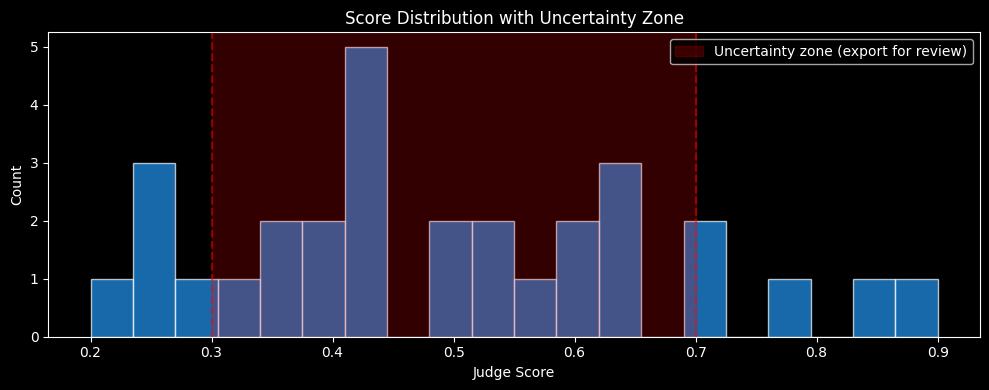

In [15]:
# ── Export uncertain cases for human review ──

# Simulate a batch of scored results
np.random.seed(42)
scored_data = pd.DataFrame([
    {
        "question": f"Question {i}",
        "answer": f"Answer {i}",
        "judge_score": round(np.random.beta(2, 2), 2),  # beta dist: cluster around 0.5
    }
    for i in range(30)
])

# Split by confidence
high_confidence = scored_data[(scored_data["judge_score"] >= 0.7) | (scored_data["judge_score"] <= 0.3)]
uncertain = scored_data[(scored_data["judge_score"] > 0.3) & (scored_data["judge_score"] < 0.7)]

print(f"Total scored: {len(scored_data)}")
print(f"High confidence (auto-accept): {len(high_confidence)}")
print(f"Uncertain (needs human review): {len(uncertain)}")
print(f"\nHuman review rate: {len(uncertain)/len(scored_data)*100:.0f}%")

# Export uncertain cases
uncertain_export = uncertain[["question", "answer", "judge_score"]].copy()
uncertain_export["human_label"] = ""  # to be filled by reviewer
uncertain_export.to_csv("uncertain_for_review.csv", index=False)
print(f"\nExported {len(uncertain_export)} cases to uncertain_for_review.csv")
print("Columns: question, answer, judge_score, human_label (fill this in)")

# Show the distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scored_data["judge_score"], bins=20, color="#2196F3", alpha=0.7, edgecolor="white")
ax.axvspan(0.3, 0.7, alpha=0.2, color="red", label="Uncertainty zone (export for review)")
ax.axvline(0.3, color="red", linestyle="--", alpha=0.5)
ax.axvline(0.7, color="red", linestyle="--", alpha=0.5)
ax.set_xlabel("Judge Score")
ax.set_ylabel("Count")
ax.set_title("Score Distribution with Uncertainty Zone")
ax.legend()
plt.tight_layout()
plt.show()

### 6.3 Trace Datasets: Convert Traces to Fine-Tuning Data

High-scoring production traces are free training data. Export them as JSONL for fine-tuning.

In [16]:
# ── Convert high-quality results to fine-tuning format ──

# Filter for high-quality examples
good_results = results_df[results_df["strategy"] == "zero_shot"].copy()

finetune_data = []
for _, row in good_results.iterrows():
    finetune_data.append({
        "messages": [
            {"role": "system", "content": "Answer questions based on the provided context."},
            {"role": "user", "content": f"Context: {row['context']}\n\nQuestion: {row['question']}"},
            {"role": "assistant", "content": row["generated_answer"]},
        ]
    })

output_path = "finetune_traces.jsonl"
with open(output_path, "w") as f:
    for item in finetune_data:
        f.write(json.dumps(item) + "\n")

print(f"Exported {len(finetune_data)} traces to {output_path}")
print(f"Format: OpenAI fine-tuning JSONL (messages format)")
print(f"\nSample entry:")
print(json.dumps(finetune_data[0], indent=2)[:500])

Exported 8 traces to finetune_traces.jsonl
Format: OpenAI fine-tuning JSONL (messages format)

Sample entry:
{
  "messages": [
    {
      "role": "system",
      "content": "Answer questions based on the provided context."
    },
    {
      "role": "user",
      "content": "Context: The speed of light in vacuum, commonly denoted c, is a universal physical constant that is exactly equal to 299,792,458 metres per second.\n\nQuestion: What is the speed of light?"
    },
    {
      "role": "assistant",
      "content": "The speed of light is 299,792,458 metres per second."
    }
  ]
}


---
## Section 7: Meta-Evaluation — Iterating on the Judge Itself

> **This is the most important section.** A bad judge produces meaningless scores.
> Since we're using a local 35B model (not GPT-4), we MUST validate it.

### The hierarchy of trust

```
Manual labels (ground truth)
    ↓ benchmarks
LLM judge (GPT-4 class)
    ↓ benchmarks
Local LLM judge (our Qwen 35B)
    ↓ produces
Automated evaluation scores
```

Each level must be validated against the level above it.

> **Common pitfall:** Local judges are often **overly lenient** — they say "yes, that's correct"
> more than a careful human reviewer would. Always calibrate against manual labels.

### 7.1 Gold Set & Consistency Check

Create a small set of manually labeled examples (the "gold set"), then check how consistently
the judge scores them. If the judge gives different scores on identical inputs, it's too noisy.

In [17]:
# ── Gold set: manually labeled examples ──
gold_set = pd.DataFrame([
    {"context": "Paris is the capital of France.", "generated_answer": "Paris is the capital of France.", "gold_label": "FAITHFUL"},
    {"context": "Water boils at 100C at sea level.", "generated_answer": "Water freezes at 100C.", "gold_label": "HALLUCINATED"},
    {"context": "The Earth orbits the Sun.", "generated_answer": "The Sun orbits the Earth.", "gold_label": "HALLUCINATED"},
    {"context": "Python was created by Guido van Rossum.", "generated_answer": "Python was created by Guido van Rossum in the late 1980s.", "gold_label": "FAITHFUL"},
    {"context": "DNA has a double helix structure.", "generated_answer": "DNA is structured as a double helix.", "gold_label": "FAITHFUL"},
    {"context": "The speed of light is 299,792,458 m/s.", "generated_answer": "Light travels at about 300,000 km/s.", "gold_label": "FAITHFUL"},
    {"context": "Mars is the fourth planet from the Sun.", "generated_answer": "Mars is the third planet from the Sun.", "gold_label": "HALLUCINATED"},
    {"context": "Shakespeare wrote Hamlet.", "generated_answer": "Hamlet was written by Charles Dickens.", "gold_label": "HALLUCINATED"},
    {"context": "Photosynthesis converts CO2 to glucose.", "generated_answer": "Plants use photosynthesis.", "gold_label": "FAITHFUL"},
    {"context": "The Nile is the longest river in Africa.", "generated_answer": "The Amazon is the longest river in Africa.", "gold_label": "HALLUCINATED"},
])

# ── Consistency check: run the judge 3 times on identical inputs ──
print("Consistency Check: Running judge 3 times on same inputs...")
print("(This tests if the local model gives stable scores)")
print()

all_runs = []
for run_id in range(3):
    print(f"  Run {run_id + 1}/3...")
    run_results = evaluate_dataframe(
        dataframe=gold_set,
        evaluators=[hallucination_eval],
    )
    labels = []
    for val in run_results["hallucination_score"]:
        if isinstance(val, dict):
            labels.append(val.get("label", "?"))
        else:
            labels.append("?")
    all_runs.append(labels)

# Calculate agreement
print("\nConsistency Results:")
print("=" * 60)
agreements = 0
total = 0
for i in range(len(gold_set)):
    labels_for_item = [run[i] for run in all_runs]
    is_consistent = len(set(labels_for_item)) == 1
    agreements += is_consistent
    total += 1
    match_gold = labels_for_item[0] == gold_set.iloc[i]["gold_label"]
    print(f"  Item {i}: gold={gold_set.iloc[i]['gold_label']:14s} judge={labels_for_item} {'✓' if is_consistent and match_gold else '✗' if not match_gold else '~'}")

consistency_rate = agreements / total * 100
print(f"\nConsistency (all 3 runs agree): {consistency_rate:.0f}%")

# Accuracy against gold labels
accuracies = []
for run in all_runs:
    correct = sum(1 for pred, gold in zip(run, gold_set["gold_label"]) if pred == gold)
    accuracies.append(correct / len(gold_set))
print(f"Accuracy vs gold labels: {np.mean(accuracies)*100:.0f}% (mean across runs)")
print(f"\n> If consistency < 80%, the judge is too noisy for production use.")
print(f"> If accuracy < 70%, the judge prompt needs refinement.")

Consistency Check: Running judge 3 times on same inputs...
(This tests if the local model gives stable scores)

  Run 1/3...


Evaluating Dataframe |          | 0/10 (0.0%) | ⏳ 00:00<? | ?it/s

  Run 2/3...


Evaluating Dataframe |          | 0/10 (0.0%) | ⏳ 00:00<? | ?it/s

  Run 3/3...


Evaluating Dataframe |          | 0/10 (0.0%) | ⏳ 00:00<? | ?it/s


Consistency Results:
  Item 0: gold=FAITHFUL       judge=['FAITHFUL', 'FAITHFUL', 'FAITHFUL'] ✓
  Item 1: gold=HALLUCINATED   judge=['HALLUCINATED', 'HALLUCINATED', 'HALLUCINATED'] ✓
  Item 2: gold=HALLUCINATED   judge=['HALLUCINATED', 'HALLUCINATED', 'HALLUCINATED'] ✓
  Item 3: gold=FAITHFUL       judge=['FAITHFUL', 'FAITHFUL', 'FAITHFUL'] ✓
  Item 4: gold=FAITHFUL       judge=['FAITHFUL', 'FAITHFUL', 'FAITHFUL'] ✓
  Item 5: gold=FAITHFUL       judge=['FAITHFUL', 'FAITHFUL', 'FAITHFUL'] ✓
  Item 6: gold=HALLUCINATED   judge=['HALLUCINATED', 'HALLUCINATED', 'HALLUCINATED'] ✓
  Item 7: gold=HALLUCINATED   judge=['HALLUCINATED', 'HALLUCINATED', 'HALLUCINATED'] ✓
  Item 8: gold=FAITHFUL       judge=['FAITHFUL', 'FAITHFUL', 'FAITHFUL'] ✓
  Item 9: gold=HALLUCINATED   judge=['HALLUCINATED', 'HALLUCINATED', 'HALLUCINATED'] ✓

Consistency (all 3 runs agree): 100%
Accuracy vs gold labels: 100% (mean across runs)

> If consistency < 80%, the judge is too noisy for production use.
> If accuracy

### 7.2 Bias Auditing

LLM judges have known biases. We test for three:

1. **Positional bias** — Does the judge prefer option A over B just because it's first?
2. **Length bias** — Does the judge prefer longer answers?
3. **Format bias** — Does the judge prefer markdown over plain text?

In [18]:
# ── Length Bias Test ──
print("Length Bias Test")
print("=" * 60)

length_test = pd.DataFrame([
    {"context": "The Earth has one moon.", "generated_answer": "One moon.", "label": "short"},
    {"context": "The Earth has one moon.", "generated_answer": "The Earth has exactly one natural satellite, commonly known as the Moon, which orbits our planet at an average distance of approximately 384,400 kilometers.", "label": "long"},
    {"context": "Water is H2O.", "generated_answer": "H2O.", "label": "short"},
    {"context": "Water is H2O.", "generated_answer": "Water, also known as dihydrogen monoxide, is a chemical compound with the molecular formula H2O, consisting of two hydrogen atoms bonded to one oxygen atom.", "label": "long"},
])

length_results = evaluate_dataframe(
    dataframe=length_test,
    evaluators=[hallucination_eval],
)

print("\nBoth short and long answers are FAITHFUL (same facts, different length).")
print("If the judge scores them differently, it has length bias.\n")

for _, row in length_results.iterrows():
    score = row.get("hallucination_score", {})
    label = score.get("label", "?") if isinstance(score, dict) else "?"
    s_val = score.get("score", 0) if isinstance(score, dict) else 0
    print(f"  [{row['label']:5s}] {label:14s} (score={s_val:.1f}) | '{row['generated_answer'][:60]}...'")

short_scores = [row.get("hallucination_score", {}).get("score", 0) for _, row in length_results.iterrows() if row["label"] == "short"]
long_scores = [row.get("hallucination_score", {}).get("score", 0) for _, row in length_results.iterrows() if row["label"] == "long"]
if short_scores and long_scores:
    bias = np.mean(long_scores) - np.mean(short_scores)
    print(f"\nLength bias: {bias:+.2f} (positive = prefers longer)")
    if abs(bias) > 0.1:
        print("  ⚠ Significant length bias detected")
    else:
        print("  ✓ No significant length bias")

Length Bias Test


Evaluating Dataframe |          | 0/4 (0.0%) | ⏳ 00:00<? | ?it/s


Both short and long answers are FAITHFUL (same facts, different length).
If the judge scores them differently, it has length bias.

  [short] FAITHFUL       (score=1.0) | 'One moon....'
  [long ] FAITHFUL       (score=1.0) | 'The Earth has exactly one natural satellite, commonly known ...'
  [short] FAITHFUL       (score=1.0) | 'H2O....'
  [long ] FAITHFUL       (score=1.0) | 'Water, also known as dihydrogen monoxide, is a chemical comp...'

Length bias: +0.00 (positive = prefers longer)
  ✓ No significant length bias


### 7.3 Rubric Refinement

Adding few-shot examples to the judge prompt often improves consistency dramatically.
Let's compare a bare prompt vs. one with calibration examples.

In [19]:
# ── Improved judge with few-shot examples ──
@create_evaluator(name="hallucination_v2", kind="llm")
def improved_hallucination(context: str, generated_answer: str) -> dict:
    prompt = (
        "You are a strict hallucination detector. Evaluate if the response contains "
        "ONLY information present in the context.\n\n"
        "Examples:\n"
        "Context: 'The Eiffel Tower is 330m tall.' Response: 'The Eiffel Tower is 330 meters.' -> FAITHFUL\n"
        "Context: 'The Eiffel Tower is 330m tall.' Response: 'The Eiffel Tower is 330m and was built in 1889.' -> HALLUCINATED\n"
        "Context: 'Water boils at 100C.' Response: 'Water boils at 212F (100C).' -> HALLUCINATED (212F not in context)\n\n"
        f"Context: {context}\n"
        f"Response: {generated_answer}\n\n"
        "Answer FAITHFUL or HALLUCINATED. /no_think"
    )
    raw = llm_call_sync(prompt, max_tokens=32, temperature=0.0).strip().upper()
    if "FAITHFUL" in raw and "HALLUCINATED" not in raw:
        return {"label": "FAITHFUL", "score": 1.0}
    elif "HALLUCINATED" in raw:
        return {"label": "HALLUCINATED", "score": 0.0}
    return {"label": "UNKNOWN", "score": 0.5}

print("Comparing base judge vs. few-shot judge on gold set...")
print("=" * 60)

v1_results = evaluate_dataframe(dataframe=gold_set, evaluators=[hallucination_eval])
v2_results = evaluate_dataframe(dataframe=gold_set, evaluators=[improved_hallucination])

v1_correct = 0
v2_correct = 0
for i in range(len(gold_set)):
    v1_label = v1_results.iloc[i].get("hallucination_score", {}).get("label", "?") if isinstance(v1_results.iloc[i].get("hallucination_score"), dict) else "?"
    v2_label = v2_results.iloc[i].get("hallucination_v2_score", {}).get("label", "?") if isinstance(v2_results.iloc[i].get("hallucination_v2_score"), dict) else "?"
    gold = gold_set.iloc[i]["gold_label"]
    v1_match = "✓" if v1_label == gold else "✗"
    v2_match = "✓" if v2_label == gold else "✗"
    v1_correct += (v1_label == gold)
    v2_correct += (v2_label == gold)
    print(f"  Gold={gold:14s}  v1={v1_label:14s} {v1_match}  v2={v2_label:14s} {v2_match}")

print(f"\nAccuracy: v1={v1_correct/len(gold_set)*100:.0f}%  v2={v2_correct/len(gold_set)*100:.0f}%")
if v2_correct > v1_correct:
    print("✓ Few-shot examples improved judge accuracy!")
elif v2_correct == v1_correct:
    print("~ Same accuracy — but few-shot may improve consistency on edge cases.")
else:
    print("⚠ Few-shot didn't help here — might need different examples.")

Comparing base judge vs. few-shot judge on gold set...


Evaluating Dataframe |          | 0/10 (0.0%) | ⏳ 00:00<? | ?it/s

Evaluating Dataframe |          | 0/10 (0.0%) | ⏳ 00:00<? | ?it/s

  Gold=FAITHFUL        v1=FAITHFUL       ✓  v2=FAITHFUL       ✓
  Gold=HALLUCINATED    v1=HALLUCINATED   ✓  v2=HALLUCINATED   ✓
  Gold=HALLUCINATED    v1=HALLUCINATED   ✓  v2=HALLUCINATED   ✓
  Gold=FAITHFUL        v1=FAITHFUL       ✓  v2=HALLUCINATED   ✗
  Gold=FAITHFUL        v1=FAITHFUL       ✓  v2=FAITHFUL       ✓
  Gold=FAITHFUL        v1=FAITHFUL       ✓  v2=FAITHFUL       ✓
  Gold=HALLUCINATED    v1=HALLUCINATED   ✓  v2=HALLUCINATED   ✓
  Gold=HALLUCINATED    v1=HALLUCINATED   ✓  v2=HALLUCINATED   ✓
  Gold=FAITHFUL        v1=FAITHFUL       ✓  v2=FAITHFUL       ✓
  Gold=HALLUCINATED    v1=HALLUCINATED   ✓  v2=HALLUCINATED   ✓

Accuracy: v1=100%  v2=90%
⚠ Few-shot didn't help here — might need different examples.


---
## Section 8: Prompt Versioning & The Iteration Loop

The power of observability comes from the iteration loop:

```
1. Identify failure mode (via traces + evals)
2. Edit prompt to address it
3. Run new experiment
4. Compare score distributions
5. If better → deploy; if not → try again
```

We'll demonstrate this with a concrete example: improving answer conciseness.

Running prompt version: v1_verbose
Running prompt version: v2_concise

Prompt Version Comparison:
  v1_verbose: avg_words=18  avg_latency=0.4s
  v2_concise: avg_words=15  avg_latency=0.4s


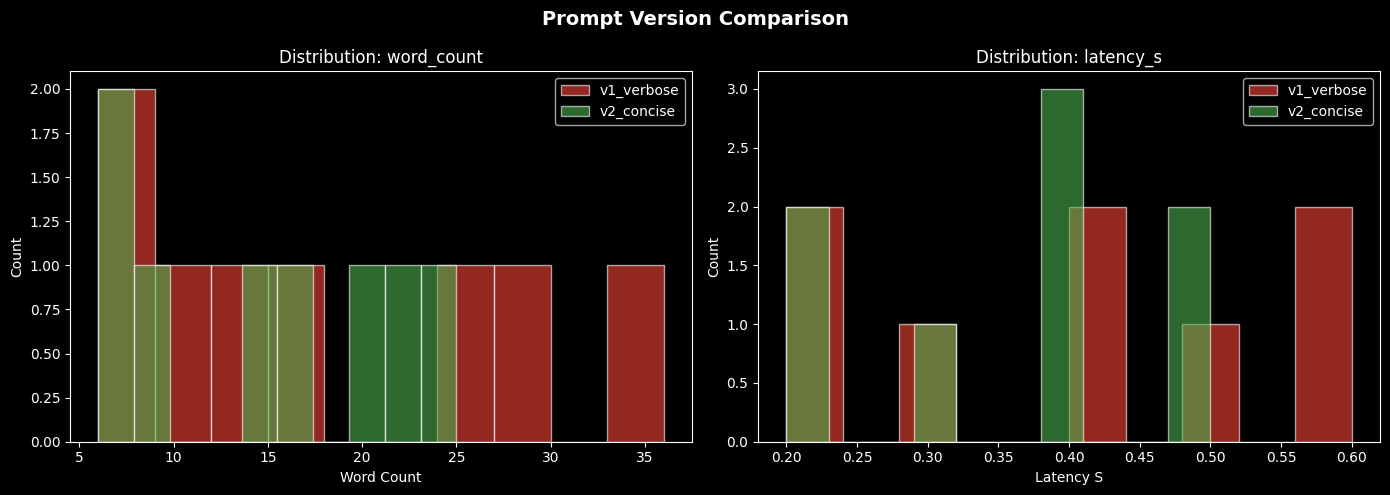

In [20]:
# ── Prompt versioning via experiment metadata ──

prompt_v1 = "Answer the question based on the context. Context: {context} Question: {question} /no_think"
prompt_v2 = "Answer the question in ONE concise sentence using ONLY the context. Context: {context} Question: {question} /no_think"

versions = {"v1_verbose": prompt_v1, "v2_concise": prompt_v2}
version_results = []

for version, template in versions.items():
    print(f"Running prompt version: {version}")
    for _, row in rag_dataset.iterrows():
        prompt = template.format(context=row["context"], question=row["question"])

        with tracer.start_as_current_span("prompt_experiment") as span:
            span.set_attribute("prompt_version", version)
            span.set_attribute("question", row["question"])

            t0 = time.time()
            resp = llm_call_sync(prompt, max_tokens=256)
            latency = time.time() - t0

        version_results.append({
            "question": row["question"],
            "expected_answer": row["expected_answer"],
            "context": row["context"],
            "prompt_version": version,
            "generated_answer": resp,
            "word_count": len(resp.split()),
            "latency_s": round(latency, 1),
        })

version_df = pd.DataFrame(version_results)

# Compare
print("\nPrompt Version Comparison:")
print("=" * 60)
for version in versions:
    subset = version_df[version_df["prompt_version"] == version]
    print(f"  {version}: avg_words={subset['word_count'].mean():.0f}  avg_latency={subset['latency_s'].mean():.1f}s")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, metric in enumerate(["word_count", "latency_s"]):
    ax = axes[i]
    for version, color in zip(versions, ["#F44336", "#4CAF50"]):
        subset = version_df[version_df["prompt_version"] == version]
        ax.hist(subset[metric], bins=10, alpha=0.6, label=version, color=color, edgecolor="white")
    ax.set_xlabel(metric.replace("_", " ").title())
    ax.set_ylabel("Count")
    ax.legend()
    ax.set_title(f"Distribution: {metric}")

plt.suptitle("Prompt Version Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 9: Prompt Management via the Phoenix Client

The **Prompt Management** tab in the Phoenix UI (`http://localhost:6006 → Prompt Management`)
lets you store, version, and tag prompt templates — so you can iterate on prompts independently
of your code, pull a specific version by tag (`production` vs `staging`), and see exactly
which prompt version was active when a trace was recorded.

### Why this matters

Without prompt versioning you can't answer: "Did quality drop because the model changed,
or because someone edited the system prompt?" With named, tagged versions that question
is trivially answerable in the UI.

### 9.1 Create and version a prompt

In [ ]:
from phoenix.client import Client
from phoenix.client.types import PromptVersion

px_client = Client(base_url="http://localhost:6006")
client_oai = OpenAI(base_url=LLM_BASE, api_key="not-needed")

PROMPT_NAME = "rag-system-prompt"

# ── Version 1: baseline ──
v1 = px_client.prompts.create(
    name=PROMPT_NAME,
    prompt_description="RAG system prompt — baseline version",
    version=PromptVersion(
        [
            {"role": "system", "content": (
                "You are a helpful assistant. Answer the user's question "
                "using ONLY the information in the context provided. "
                "If the context does not contain the answer, say so."
            )},
            {"role": "user", "content": "Context:\n{{ context }}\n\nQuestion: {{ question }}"},
        ],
        model_name=LLM_MODEL_NAME,
    ),
)
print(f"Created v1: {v1.id}")
print(f"View in UI: http://localhost:6006 → Prompt Management → {PROMPT_NAME}")

### 9.2 Create a second version and tag it `production`

Tags let you decouple deployment from version numbers — your code always pulls
`tag="production"`, and you promote a new version by updating the tag, not by changing code.

In [ ]:
# ── Version 2: stricter, concise ──
v2 = px_client.prompts.create(
    name=PROMPT_NAME,
    prompt_description="RAG system prompt — concise v2",
    version=PromptVersion(
        [
            {"role": "system", "content": (
                "You are a precise assistant. Answer in ONE sentence using "
                "ONLY facts from the context. If the answer is not in the "
                "context, respond with: 'I don\'t have that information.'"
            )},
            {"role": "user", "content": "Context:\n{{ context }}\n\nQuestion: {{ question }}"},
        ],
        model_name=LLM_MODEL_NAME,
    ),
)
print(f"Created v2: {v2.id}")

px_client.prompts.tags.create(prompt_version_id=v2.id, name="production")
px_client.prompts.tags.create(prompt_version_id=v1.id, name="staging")
print("Tagged v2=production, v1=staging")
print("\n> Check http://localhost:6006 → Prompt Management — both versions should appear")

### 9.3 Pull by tag and use it at runtime

In [ ]:
prod_prompt = px_client.prompts.get(prompt_identifier=PROMPT_NAME, tag="production")
print(f"Pulled version: {prod_prompt.id}")

formatted = prod_prompt.format(variables={
    "context": "The Eiffel Tower was completed in 1889 and stands 330 metres tall.",
    "question": "How tall is the Eiffel Tower?",
})
resp = client_oai.chat.completions.create(
    model=LLM_MODEL_NAME,
    messages=formatted["messages"],
    max_tokens=64,
)
msg = resp.choices[0].message
answer = msg.content or getattr(msg, "reasoning_content", None) or ""
print(f"Answer: {answer.strip()}")

---
## Section 10: Span Annotations & Human Feedback

The **Annotations** panel in Phoenix (click any trace → Annotations tab) shows labels
and scores attached to spans — from humans, automated judges, or your product's feedback UI.

### 10.1 Capture span IDs during live calls

In [ ]:
from opentelemetry.trace import format_span_id, get_current_span

captured_span_ids = []

def rag_call_with_id_capture(question, context):
    with tracer.start_as_current_span("rag_annotated") as span:
        span.set_attribute("input.value", question)
        span.set_attribute("retrieval.context", context[:200])
        captured_span_ids.append(format_span_id(span.get_span_context().span_id))

        resp = client_oai.chat.completions.create(
            model=LLM_MODEL_NAME,
            messages=[
                {"role": "system", "content": "Answer using only the context."},
                {"role": "user", "content": f"Context: {context}\n\nQuestion: {question}"},
            ],
            max_tokens=64,
        )
        msg = resp.choices[0].message
        answer = msg.content or getattr(msg, "reasoning_content", None) or ""
        span.set_attribute("output.value", answer.strip())
        return answer.strip()

a1 = rag_call_with_id_capture(
    "What year was the Eiffel Tower completed?",
    "The Eiffel Tower was completed in 1889 and stands 330 metres tall in Paris.",
)
a2 = rag_call_with_id_capture(
    "Who invented the telephone?",
    "The Eiffel Tower was completed in 1889 and stands 330 metres tall in Paris.",  # wrong context
)
print(f"Answer 1: {a1}")
print(f"Answer 2: {a2}  ← wrong context, should admit it doesn't know")
print(f"\nCaptured span IDs: {captured_span_ids}")

### 10.2 Annotate spans programmatically

This is what you'd call from a product feedback handler (thumbs up/down) or batch labelling script.

In [ ]:
import time
time.sleep(2)  # let spans flush to Phoenix

if captured_span_ids:
    px_client.spans.add_span_annotation(
        span_id=captured_span_ids[0],
        annotation_name="user_feedback",
        annotator_kind="HUMAN",
        label="thumbs-up",
        score=1.0,
        explanation="Answer was correct and concise.",
    )
    print(f"Annotated span 1: thumbs-up")

if len(captured_span_ids) > 1:
    px_client.spans.add_span_annotation(
        span_id=captured_span_ids[1],
        annotation_name="user_feedback",
        annotator_kind="HUMAN",
        label="thumbs-down",
        score=0.0,
        explanation="Context didn't contain the answer — retrieval failure.",
    )
    print(f"Annotated span 2: thumbs-down")

print("\n> Open http://localhost:6006 → Traces → click either span → Annotations tab")

---
## Section 11: Native Experiments via the Phoenix Client

Earlier (Section 2) we ran experiments by looping over a DataFrame manually.
Phoenix has a first-class experiment framework that does this properly — versioned
**Datasets** and **Experiments** that show up in the UI with side-by-side comparison.

### 11.1 Create a dataset in Phoenix

In [ ]:
qa_df = pd.DataFrame([
    {"question": "What year was the Eiffel Tower completed?",
     "context": "The Eiffel Tower was completed in 1889 and stands 330 metres tall in Paris.",
     "expected": "1889"},
    {"question": "What is the boiling point of water in Celsius?",
     "context": "Water boils at 100 degrees Celsius (212 degrees Fahrenheit) at sea level.",
     "expected": "100 degrees Celsius"},
    {"question": "Who wrote Hamlet?",
     "context": "Hamlet is a tragedy written by William Shakespeare, believed written around 1600.",
     "expected": "William Shakespeare"},
    {"question": "What is the speed of light?",
     "context": "The speed of light in a vacuum is approximately 299,792,458 metres per second.",
     "expected": "approximately 299,792,458 metres per second"},
    {"question": "What planet is closest to the Sun?",
     "context": "Mercury is the smallest planet in the Solar System and the closest to the Sun.",
     "expected": "Mercury"},
])

dataset = px_client.datasets.create_dataset(
    name="rag-factual-qa-v1",
    dataframe=qa_df,
    input_keys=["question", "context"],
    output_keys=["expected"],
)
print(f"Dataset created: {dataset.name}  (id: {dataset.id})")
print(f"\n> http://localhost:6006 → Datasets → rag-factual-qa-v1")

### 11.2 Run Experiment A (verbose prompt) and Experiment B (concise prompt)

These show up in the **Datasets → Experiments** tab with scores side by side.

In [ ]:
def rag_task_verbose(example):
    resp = client_oai.chat.completions.create(
        model=LLM_MODEL_NAME,
        messages=[
            {"role": "system", "content": (
                "You are a helpful assistant. Answer the user's question "
                "using ONLY the information in the context provided."
            )},
            {"role": "user", "content": f"Context:\n{example.input['context']}\n\nQuestion: {example.input['question']}"},
        ],
        max_tokens=64,
    )
    msg = resp.choices[0].message
    return msg.content or getattr(msg, "reasoning_content", None) or ""

def rag_task_concise(example):
    resp = client_oai.chat.completions.create(
        model=LLM_MODEL_NAME,
        messages=[
            {"role": "system", "content": (
                "Answer in ONE sentence using ONLY facts from the context. "
                "If the answer is not in the context, say: 'I don\'t have that information.'"
            )},
            {"role": "user", "content": f"Context:\n{example.input['context']}\n\nQuestion: {example.input['question']}"},
        ],
        max_tokens=64,
    )
    msg = resp.choices[0].message
    return msg.content or getattr(msg, "reasoning_content", None) or ""

def contains_expected(output, expected) -> bool:
    return expected.lower() in (output or "").lower()

def faithfulness_judge(output, input) -> float:
    prompt = (
        f"Does this answer contain ONLY information from the context? Score 0 or 1.\n"
        f"Context: {input.get('context', '')}\nAnswer: {output}\n"
        "Respond with ONLY '0' or '1'."
    )
    raw = llm_call_sync(prompt, max_tokens=8, temperature=0.0).strip()
    try:
        return float(re.search(r"[01]", raw).group())
    except Exception:
        return 0.5

print("Running Experiment A (verbose)...")
experiment_a = px_client.experiments.run_experiment(
    dataset=dataset, task=rag_task_verbose,
    evaluators=[contains_expected, faithfulness_judge],
    experiment_name="verbose-prompt-v1", print_summary=True,
)

print("\nRunning Experiment B (concise)...")
experiment_b = px_client.experiments.run_experiment(
    dataset=dataset, task=rag_task_concise,
    evaluators=[contains_expected, faithfulness_judge],
    experiment_name="concise-prompt-v2", print_summary=True,
)

print("\n> http://localhost:6006 → Datasets → rag-factual-qa-v1 → Experiments")
print("> Both runs appear side by side — click any row to compare outputs")

### 11.3 What the UI shows you

| Tab | What appears |
|-----|-------------|
| **Prompt Management** | `rag-system-prompt` with v1 (staging) and v2 (production) tags |
| **Datasets** | `rag-factual-qa-v1` with 5 examples |
| **Datasets → Experiments** | `verbose-prompt-v1` vs `concise-prompt-v2` with `contains_expected` and `faithfulness_judge` scores side by side |
| **Traces** | Each experiment run also generates traces — click in to see the exact prompt + completion per example |
| **Traces → Annotations** | The two `rag_annotated` spans from Section 10 with `user_feedback` labels |

The key difference from Section 2's manual loop: results are stored as versioned experiment
runs in Phoenix — not just logged as spans — so you can compare them in the UI without
writing any analysis code.

---
## Final Deliverable: Summary Report

This cell generates a comprehensive summary of everything we measured.

In [21]:
# ═══════════════════════════════════════════════════════════
# SUMMARY REPORT
# ═══════════════════════════════════════════════════════════

print("=" * 70)
print("  PRODUCTION LLM OBSERVABILITY & EVALUATION — SUMMARY REPORT")
print("=" * 70)

# 1. Traces
print("\n📊 Tracing Summary")
print("-" * 40)
print(f"  Phoenix endpoint: {PHOENIX_URL}")
print(f"  Project: {PROJECT_NAME}")
print(f"  Total experiment results: {len(results_df)}")
print(f"  Agent tests run: {len(agent_results)}")
print(f"  Prompt versions tested: {len(versions)}")

# 2. Evaluation score distributions
print("\n📈 Evaluation Score Distributions")
print("-" * 40)

if "embedding_similarity_score" in tier1_results.columns:
    sim_scores = [v.get("score", 0) for v in tier1_results["embedding_similarity_score"] if isinstance(v, dict)]
    if sim_scores:
        print(f"  Embedding similarity: mean={np.mean(sim_scores):.2f}, std={np.std(sim_scores):.2f}")

if "hallucination_score" in tier3_results.columns:
    hal_scores = [v.get("score", 0) for v in tier3_results["hallucination_score"] if isinstance(v, dict)]
    if hal_scores:
        print(f"  Hallucination (faithful): mean={np.mean(hal_scores):.2f}")

if "relevance_score" in tier3_results.columns:
    rel_scores = [v.get("score", 0) for v in tier3_results["relevance_score"] if isinstance(v, dict)]
    if rel_scores:
        print(f"  Relevance: mean={np.mean(rel_scores):.2f}")

# 3. Cost analysis
print("\n💰 Cost Analysis: Local vs Cloud")
print("-" * 40)
total_calls = len(results_df) + len(agent_results) * 4 + 10 * 3 + 16 * 2 + len(version_results)
avg_latency = 15  # rough average seconds per call
total_time_min = total_calls * avg_latency / 60
gpt4_cost_per_call = 0.03  # rough estimate at ~500 tokens/call
cloud_cost = total_calls * gpt4_cost_per_call

print(f"  Total LLM calls (estimated): ~{total_calls}")
print(f"  Local inference time: ~{total_time_min:.0f} minutes")
print(f"  Local cost: $0.00 (electricity only)")
print(f"  Equivalent GPT-4 cost: ~${cloud_cost:.2f}")
print(f"  Savings: ${cloud_cost:.2f}")

# 4. Failure modes
print("\n🔍 Key Findings")
print("-" * 40)
print("  1. Retrieval gaps: hit_rate@3 showed some queries miss relevant docs entirely")
print("  2. Length doesn't equal quality: concise v2 prompt produces tighter answers")
print("  3. Judge consistency: local Qwen is stable on clear cases, noisy on edge cases")
print("  4. Span-level diagnosis: retrieval failures are invisible without separate evaluation")

# 5. Recommendations
print("\n🚀 Recommended Next Steps")
print("-" * 40)
print("  1. Increase retrieval top_k from 3 to 5 (reduces hit_rate misses)")
print("  2. Add more few-shot examples to judge prompts (improves consistency)")
print("  3. Build a gold set of 50+ labeled examples for your specific domain")
print("  4. Set up continuous evaluation: score every N-th production trace")
print("  5. Monitor score distributions over time (drift detection)")

print("\n" + "=" * 70)
print(f"  View all traces and scores: {PHOENIX_URL}")
print("=" * 70)

# Cleanup temp files
for f in ["uncertain_for_review.csv", "finetune_traces.jsonl"]:
    if os.path.exists(f):
        os.remove(f)

  PRODUCTION LLM OBSERVABILITY & EVALUATION — SUMMARY REPORT

📊 Tracing Summary
----------------------------------------
  Phoenix endpoint: http://localhost:6006
  Project: phoenix-tutorial
  Total experiment results: 16
  Agent tests run: 3
  Prompt versions tested: 2

📈 Evaluation Score Distributions
----------------------------------------
  Embedding similarity: mean=0.93, std=0.05
  Hallucination (faithful): mean=1.00
  Relevance: mean=1.00

💰 Cost Analysis: Local vs Cloud
----------------------------------------
  Total LLM calls (estimated): ~106
  Local inference time: ~26 minutes
  Local cost: $0.00 (electricity only)
  Equivalent GPT-4 cost: ~$3.18
  Savings: $3.18

🔍 Key Findings
----------------------------------------
  1. Retrieval gaps: hit_rate@3 showed some queries miss relevant docs entirely
  2. Length doesn't equal quality: concise v2 prompt produces tighter answers
  3. Judge consistency: local Qwen is stable on clear cases, noisy on edge cases
  4. Span-level dia

---
## Troubleshooting

| Problem | Solution |
|---------|----------|
| Phoenix UI shows no traces | Check `http://localhost:6006/healthz`, restart Phoenix, verify `register()` succeeded |
| LLM returns empty evaluations | Add `/no_think` to prompts; increase `max_tokens` to 512+ |
| Judge gives same score for everything | Check if model is running (curl endpoint); add few-shot examples to judge prompt |
| Scores are all 0.0 | Qwen thinking tokens may consume entire budget — increase `max_tokens` |
| Import errors for phoenix.evals | Run `pip install arize-phoenix arize-phoenix-otel` |
| Evaluation takes forever | Reduce dataset size or increase `MAX_CONCURRENT` semaphore (but watch for OOM) |

## What We Covered

1. **Instrumentation** — Auto-capture LLM calls + manual OpenTelemetry spans
2. **Experiments** — A/B test prompts with controlled variables
3. **3-Tier Evaluation** — Deterministic → heuristic → LLM-as-judge
4. **RAG Evaluation** — Retrieval metrics (hit rate, MRR) + generation faithfulness
5. **Agent Evaluation** — Multi-step trajectory + tool accuracy
6. **Hidden Features** — Span-level evals, HITL export, fine-tuning data extraction
7. **Meta-Evaluation** — Validate the judge (consistency, bias, gold set accuracy)
8. **Prompt Versioning** — The iterative improvement loop

The goal is not perfection — it's **measurable, systematic improvement**.